# Low-Rank Approximation

In [1]:
import torch
import numpy as np
import LinearSampling.Posteriors as lsp
from torch.utils.data import DataLoader, Dataset
from functorch import make_functional
from torch.func import functional_call, vmap, jacrev, jvp

torch.set_default_dtype(torch.float64)

class toy_dataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i], self.y[i]
    
class CustomModule(torch.nn.Module):
    def __init__(self, layer_width):
        super().__init__()
        self.width = layer_width

    def forward(self, x):
        return x / self.width**0.5
    
class variable_mlp(torch.nn.Module):
    def __init__(self,layer_width,nonlin):
        super().__init__()
        self.layer_width = layer_width
        if nonlin=='tanh':
            act = torch.nn.Tanh()
        elif nonlin=='relu':
            act = torch.nn.ReLU()
        mod_list = torch.nn.ModuleList()
        for i in range(len(self.layer_width)-1):
            mod_list.append(torch.nn.Linear(layer_width[i],layer_width[i+1], bias=True))
            mod_list.append(act)
            mod_list.append(CustomModule(layer_width[i]))
        mod_list.append(torch.nn.Linear(self.layer_width[-1],1, bias=True))
        self.network = torch.nn.Sequential(*mod_list)

    # Return full output of nn
    def forward(self,x):
        return self.network(x) 
    
def weights_init(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.normal_(m.weight, 0, 1)

def jacobian(net, X):
    fnet, params = make_functional(net)
    def fnet_single(params, x):
        return fnet(params, x.unsqueeze(0)).squeeze(0)
    J = vmap(jacrev(fnet_single), (None, 0))(params, X)
    J = J[-2].detach().flatten(1).detach() # For last-layer test
    return J

def jacobian_full(net, X):
    fnet, params = make_functional(net)
    def fnet_single(params, x):
        return fnet(params, x.unsqueeze(0)).squeeze(0)
    J = vmap(jacrev(fnet_single), (None, 0))(params, X)
    J = [j.detach().flatten(1) for j in J]
    J = torch.cat(J,dim=1).detach()
    return J


c:\Users\s4531973\Documents\PhD\Code\ll_uq\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### --- Dependencies --- ###
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from cuqls.posterior import Cuqls
from utils.models import mlp
import time
import configparser
import utils.datasets
import json
import utils.regression_util as utility
import matplotlib.pyplot as plt

dataset = 'energy'

# Get hyperparameters from config file
config = configparser.ConfigParser()
config.read('utils/regression.ini')
df = utils.datasets.read_regression(dataset)
n_experiment = config.getint(dataset,'n_experiment')
input_start = config.getint(dataset,'input_start')
input_dim = config.getint(dataset,'input_dim')
target_dim = config.getint(dataset,'target_dim')
hidden_sizes = json.loads(config.get(dataset,'hidden_sizes'))
epochs = config.getint(dataset,'epochs')
lr = config.getfloat(dataset,'lr')
de_epochs = config.getint(dataset,'de_epochs')
de_lr = config.getfloat(dataset,'de_lr')
weight_decay = config.getfloat(dataset,'weight_decay')
nuqls_S = config.getint(dataset,'nuqls_S')
nuqls_epoch = config.getint(dataset,'nuqls_epoch')
nuqls_lr = config.getfloat(dataset,'nuqls_lr')

# Fixed parameters
train_ratio = 0.7
normalize = True
batch_size = 200
mse_loss = nn.MSELoss(reduction='mean')
nll = torch.nn.GaussianNLLLoss()
S = 10

# Give dataframe summary
print("--- Loading dataset {} --- \n".format(dataset))

## Num of points and dimension of data
num_points = len(df)
dimension = len(df.columns)-1

train_size = int(num_points*train_ratio)
n = train_size
validation_size = int(num_points*((1-train_ratio)/2))
test_size = int(num_points - train_size - validation_size)
dataset_numpy = df.values

# Normalize the dataset
if normalize:
    mx = dataset_numpy[:,input_start:input_dim].mean(0)
    my = dataset_numpy[:,target_dim].mean(0)
    sx = dataset_numpy[:,input_start:input_dim].std(0)
    sx = np.where(sx==0,1,sx)
    sy = dataset_numpy[:,target_dim].std(0)
    sy = np.where(sy==0,1,sy)

np.random.shuffle(dataset_numpy) # Randomness
training_set, validation_set, test_set = dataset_numpy[:train_size,:], dataset_numpy[train_size:train_size+validation_size], dataset_numpy[train_size+validation_size:,:]

train_dataset = utils.datasets.RegressionDataset(training_set, 
                                input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                mX=mx, sX=sx, my=my, sy=sy)
validation_dataset = utils.datasets.RegressionDataset(validation_set, 
                                input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                mX=mx, sX=sx, my=my, sy=sy)
test_dataset = utils.datasets.RegressionDataset(test_set, 
                                input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                mX=mx, sX=sx, my=my, sy=sy)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
full_train_loader = DataLoader(train_dataset, len(train_dataset))
X, _  = next(iter(full_train_loader))

test_loader = DataLoader(test_dataset, batch_size=test_size, shuffle=False)
_, test_y = next(iter(test_loader))

calibration_test_loader = DataLoader(test_dataset,1)
calibration_test_loader_val = DataLoader(validation_dataset,len(validation_dataset))
_, val_y = next(iter(calibration_test_loader_val))

net = mlp(input_size=input_dim-input_start, hidden_sizes=hidden_sizes, output_size=1, activation='tanh', flatten=False, bias=True).to(dtype=torch.float64)
net.apply(utility.weights_init)

if dataset=='kin8nm' or dataset=='wine' or dataset=='naval' or dataset=='protein' or dataset=='song':
    optimizer = torch.optim.SGD(net.parameters(),lr=lr, weight_decay=weight_decay, momentum=0.9)
    scheduler = None
else:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=epochs*10, power=0.5)

# Run the training loop
for epoch in tqdm(range(epochs)):
    loss = utility.train(train_loader, net, optimizer=optimizer, loss_function=mse_loss, scheduler=scheduler)
    test_loss = utility.test(test_loader, net, my=0, sy=1, loss_function=mse_loss)

total_norm = 0
for p in net.parameters():
    if p.requires_grad_:
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm.item() ** 2
total_norm = total_norm ** (1. / 2)

--- Loading dataset energy --- 



100%|██████████| 1500/1500 [00:07<00:00, 189.02it/s]


C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\2477858331.py:54: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.make_functional` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.functional_call` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  fnet, params = make_functional(net)
100%|██████████| 100/100 [00:00<00:00, 199.20it/s, mean_sq_loss=0.0365, mean_grad_norm=2.36, gpu_mem=0]


Linear sampling training complete.


100%|██████████| 100/100 [00:00<00:00, 164.44it/s, mean_sq_loss=0.00312, mean_grad_norm=2.29, gpu_mem=0]


Linear sampling training complete.


 33%|███▎      | 1/3 [00:01<00:02,  1.21s/it]

...

Linear sampling training complete.


100%|██████████| 100/100 [00:00<00:00, 167.67it/s, mean_sq_loss=0.0364, mean_grad_norm=2.09, gpu_mem=0]


Linear sampling training complete.


100%|██████████| 3/3 [00:03<00:00,  1.23s/it]


Linear sampling training complete.


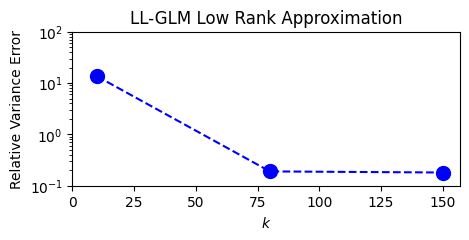

In [ ]:
S = 100
epochs = 5000
lr = 1e-1
scale = 1
num_repeats = 2
J = jacobian(net, X)
num_ranks = 10
rank_array = np.linspace(10,J.shape[1],num_ranks)
norm_diff_list = []

import importlib
importlib.reload(lsp)

ll_glm = lsp.Posterior(network=net,
                        glm_type='LL',
                        task='regression',
                        precision='double')

res = ll_glm.train(train=train_dataset,
                        bs=n, 
                        gamma=scale, 
                        S=S, 
                        epochs=epochs, 
                        lr=lr, 
                        mu=0.9, 
                        verbose=True)
ll_predictions_full_rank = ll_glm.test(test_dataset, bs=batch_size)


for k in tqdm(rank_array):
    norm_diff_repeat_list = []
    for _ in range(num_repeats):
        ll_glm = lsp.Posterior(network=net,
                        glm_type='LL',
                        task='regression',
                        precision='double')

        res = ll_glm.train(train=train_dataset,
                                bs=n, 
                                gamma=scale, 
                                S=S, 
                                epochs=epochs, 
                                lr=lr, 
                                mu=0.9, 
                                verbose=True,
                                rank_restriction=int(k))
        ll_predictions_low_rank = ll_glm.test(test_dataset, bs=batch_size)

        norm_diff_repeat_list.append(torch.linalg.norm(ll_predictions_full_rank.var(0) - ll_predictions_low_rank.var(0)) / torch.linalg.norm(ll_predictions_full_rank.var(0)))

    norm_diff_list.append(torch.tensor(norm_diff_repeat_list).mean())

f, (ax) = plt.subplots(1,1, figsize=(5,2))

ax.plot(rank_array, norm_diff_list, color='b', linestyle='--', marker='o', markersize=10)
ax.set_ylabel('Relative Variance Error')
ax.set_yscale('log')
ax.set_yticks([1e-1,1e0,1e1,1e2])
ax.set_xlabel('$k$')
ax.set_xticks([0,25,50,75,100,125,150])
ax.set_title("LL-GLM Low Rank Approximation")

f.savefig('results/paper/ll_glm_low_rank_approx.pdf', format='pdf', bbox_inches='tight')

# UCI Datasets in one plot

In [5]:
### --- Dependencies --- ###
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from cuqls.posterior import Cuqls
from utils.models import mlp
import time
import configparser
import utils.datasets
import json
import utils.regression_util as utility
import matplotlib.pyplot as plt

--- Loading dataset ccpp --- 



  0%|          | 0/2 [00:00<?, ?it/s]C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\2477858331.py:54: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.make_functional` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.functional_call` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  fnet, params = make_functional(net)
100%|██████████| 100/100 [00:07<00:00, 13.67it/s]
C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\2477858331.py:62: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.make_functional` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.functional_call` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration 

--- Loading dataset yacht --- 



  0%|          | 0/2 [00:00<?, ?it/s]C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\2477858331.py:54: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.make_functional` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.functional_call` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  fnet, params = make_functional(net)
100%|██████████| 1000/1000 [00:02<00:00, 347.96it/s]
C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\2477858331.py:62: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.make_functional` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.functional_call` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migrati

--- Loading dataset kin8nm --- 



100%|██████████| 2/2 [01:22<00:00, 41.37s/it]


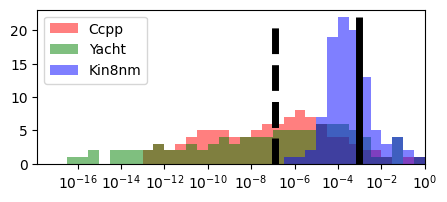

In [ ]:
# datasets = ['energy', 'concrete', 'wine', ]
datasets = ['ccpp', 'yacht', 'kin8nm']
colors = ['r','g','b','y','c','p']

f,(ax1) = plt.subplots(1,1, figsize=(5,2))
bins = (10.)**(np.arange(-17,0.5,0.5))

for idx,dataset in enumerate(datasets):
    # Get hyperparameters from config file
    config = configparser.ConfigParser()
    config.read('utils/regression.ini')
    n_experiment = config.getint(dataset,'n_experiment')
    input_start = config.getint(dataset,'input_start')
    input_dim = config.getint(dataset,'input_dim')
    target_dim = config.getint(dataset,'target_dim')
    hidden_sizes = json.loads(config.get(dataset,'hidden_sizes'))
    epochs = config.getint(dataset,'epochs')
    lr = config.getfloat(dataset,'lr')
    weight_decay = config.getfloat(dataset,'weight_decay')

    # Fixed parameters
    train_ratio = 0.7
    normalize = True
    batch_size = 200
    mse_loss = nn.MSELoss(reduction='mean')
    nll = torch.nn.GaussianNLLLoss()

    # Give dataframe summary

    print("--- Loading dataset {} --- \n".format(dataset))
    df = utils.datasets.read_regression(dataset)

    ## Num of points and dimension of data
    num_points = len(df)
    dimension = len(df.columns)-1

    train_size = int(num_points*train_ratio)
    n = train_size
    validation_size = int(num_points*((1-train_ratio)/2))
    test_size = int(num_points - train_size - validation_size)
    dataset_numpy = df.values

    # Normalize the dataset
    if normalize:
        mx = dataset_numpy[:,input_start:input_dim].mean(0)
        my = dataset_numpy[:,target_dim].mean(0)
        sx = dataset_numpy[:,input_start:input_dim].std(0)
        sx = np.where(sx==0,1,sx)
        sy = dataset_numpy[:,target_dim].std(0)
        sy = np.where(sy==0,1,sy)

    num_repeats = 5
    sv_before_list = []
    sv_after_list = []
    sv_full_list = []
    for _ in tqdm(range(num_repeats)):

        np.random.shuffle(dataset_numpy) # Randomness
        training_set, validation_set, test_set = dataset_numpy[:train_size,:], dataset_numpy[train_size:train_size+validation_size], dataset_numpy[train_size+validation_size:,:]

        train_dataset = utils.datasets.RegressionDataset(training_set, 
                                        input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                        mX=mx, sX=sx, my=my, sy=sy)
        validation_dataset = utils.datasets.RegressionDataset(validation_set, 
                                        input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                        mX=mx, sX=sx, my=my, sy=sy)
        test_dataset = utils.datasets.RegressionDataset(test_set, 
                                        input_start=input_start, input_dim=input_dim, target_dim=target_dim,
                                        mX=mx, sX=sx, my=my, sy=sy)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        full_train_loader = DataLoader(train_dataset, len(train_dataset))
        X, _  = next(iter(full_train_loader))

        test_loader = DataLoader(test_dataset, batch_size=test_size, shuffle=False)
        _, test_y = next(iter(test_loader))

        calibration_test_loader = DataLoader(test_dataset,1)
        calibration_test_loader_val = DataLoader(validation_dataset,len(validation_dataset))
        _, val_y = next(iter(calibration_test_loader_val))

        net = mlp(input_size=input_dim-input_start, hidden_sizes=hidden_sizes, output_size=1, activation='tanh', flatten=False, bias=True).to(dtype=torch.float64)
        net.apply(utility.weights_init)

        # Before training
        J = jacobian(net, X)
        sv_before_list.append(torch.linalg.svdvals(J))

        if dataset=='kin8nm' or dataset=='wine' or dataset=='naval' or dataset=='protein' or dataset=='song':
            optimizer = torch.optim.SGD(net.parameters(),lr=lr, weight_decay=weight_decay, momentum=0.9)
            scheduler = None
        else:
            optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=epochs*10, power=0.5)

        for epoch in tqdm(range(epochs)):
            loss = utility.train(train_loader, net, optimizer=optimizer, loss_function=mse_loss, scheduler=scheduler)
            test_loss = utility.test(test_loader, net, my=0, sy=1, loss_function=mse_loss)

        total_norm = 0
        for p in net.parameters():
            if p.requires_grad_:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** (1. / 2)

        # After training
        J = jacobian(net, X)
        sv_after_list.append(torch.linalg.svdvals(J))

        # NTK
        Jfull = jacobian_full(net, X)
        sv_full_list.append(torch.linalg.svdvals(Jfull))

    # Jacobian last-layer plot
    # Create change histogram
    h = ax1.hist(torch.square(torch.stack(sv_after_list, 1)).mean(1) / torch.square(torch.stack(sv_after_list, 1)).mean(1).max(), bins=bins, color=colors[idx], alpha=0.5, label=f'{dataset.capitalize()}')
    ax1.vlines(x=torch.finfo(torch.float32).eps, ymin=0, ymax=h[0].max(), linestyles='--', linewidth=5, color='k')
    ax1.vlines(x=torch.finfo(torch.float16).eps, ymin=0, ymax=h[0].max(), linestyles='-', linewidth=5, color='k')

ax1.legend()
ax1.set_xscale('log')
ax1.set_xlim(right=1)
plt.savefig(f'results/paper/uci_2_sv_hist.pdf', format='pdf', bbox_inches='tight')


In [ ]:
def jacobian_full(net, X):
    fnet, params = make_functional(net)
    def fnet_single(params, x):
        return fnet(params, x.unsqueeze(0)).squeeze(0)
    J = vmap(jacrev(fnet_single), (None, 0))(params, X)
    J = [j.detach().flatten(1) for j in J]
    J = torch.cat(J,dim=1).detach()
    return J

Jfull = jacobian_full(net, X)
sv_full = torch.linalg.svd(Jfull, full_matrices=False)[1]

f,(ax1, ax2) = plt.subplots(1,2, figsize=(10,2))

# Create cut-off histogram
bins = (10.)**(np.arange(-17,0,1))
ax1.set_xscale('log')
h = ax1.hist(sv_full / sv_full.max(), bins=bins, color='b', alpha=0.5, label='$J / ||J||_2$')
ax1.vlines(x=torch.finfo(torch.float32).eps, ymin=0, ymax=h[0].max(), linestyles='--', linewidth=5, color='r', label=r'$\epsilon(\text{float32})$')
ax1.legend()

# Create cut-off histogram
bins = (10.)**(np.arange(-17,0,1))
ax2.set_xscale('log')
h = ax2.hist(torch.square(sv_full) / torch.square(sv_full).max(), bins=bins, color='b', alpha=0.5, label='$J^T J / ||J^T J||_2$')
ax2.vlines(x=torch.finfo(torch.float32).eps, ymin=0, ymax=h[0].max(), linestyles='--', linewidth=5, color='r', label=r'$\epsilon(\text{float32})$')
ax2.legend()

# plt.savefig(f'paper/ck/{dataset}_sv_hist.pdf', format='pdf', bbox_inches='tight')

# Image Classification

100%|██████████| 600/600 [01:26<00:00,  6.94it/s]
C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\81581894.py:67: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  min_bin = np.floor(np.log10(min(minval)))
C:\Users\s4531973\AppData\Local\Temp\ipykernel_22884\81581894.py:68: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  bins = (10.)**(np.arange(min_bin,1,0.25))


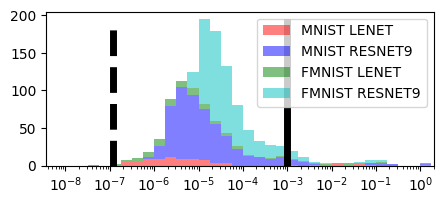

In [ ]:
import torch
from models import *
import utils.classification_dataset
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import itertools
torch.set_default_dtype(torch.float32)

# datasets = ['cifar10', 'svhn']
# models = ['resnet9','resnet50']

datasets = ['mnist', 'fmnist']
models = ['lenet','resnet9']

colors = ['r','b','g','c']
svalues = []
labels = []
minval = []

for idx, (dataset, model) in enumerate(itertools.product(datasets, models)):

    if model == 'resnet9':
        if dataset == 'svhn' or dataset == 'cifar10':
            network = ResNet9(in_channels=3, num_classes=10, p=0)
        else:
            network = ResNet9(in_channels=1, num_classes=10, p=0)
    if model == 'resnet50':
        if dataset == 'svhn' or dataset == 'cifar10':
            network = ResNet50(in_channels=3, num_classes=10, p=0)
        else:
            network = ResNet50(in_channels=1, num_classes=10, p=0)
    elif model == 'lenet':
        network = LeNet5()
    model_dict = torch.load(f'saved_models/{model}_trained_{dataset}.pt', weights_only=True, map_location='cpu')
    if 'params' in model_dict.keys():
        network.load_state_dict(model_dict['params'])
    else:
        network.load_state_dict(model_dict)
    child_list = list(network.children())
    if len(child_list) > 1:
        child_list = child_list
    elif len(child_list) == 1:
        child_list = child_list[0]
    first_layers = child_list[:-1]
    final_layer = child_list[-1]
    llp = list(final_layer.parameters())[0].size().numel()
    num_output = list(final_layer.parameters())[0].shape[0]
    ck = torch.nn.Sequential(*first_layers)

    loaded_dataset = utils.classification_dataset.load_dataset(name=dataset, subsample=False)

    train_loader = loaded_dataset.trainloader(batch_size=100)
    JX = []
    for x,_ in tqdm.tqdm(train_loader):
        JX.append(ck(x).detach())
    Jx = torch.cat(JX,dim=0)
    CK = Jx.T @ Jx
    sv_squared_vals = torch.linalg.svdvals(CK.to(torch.float32)).detach()
    svalues.append(sv_squared_vals / sv_squared_vals.max())
    labels.append(f'{dataset.upper()} {model.upper()}')
    minval.append((sv_squared_vals / sv_squared_vals.max()).min())

f,(ax1) = plt.subplots(1,1, figsize=(5,2))
bins = (10.)**(np.arange(-17,0.5,0.5))

min_bin = np.floor(np.log10(min(minval)))
bins = (10.)**(np.arange(min_bin,1,0.25))  
h = ax1.hist(svalues, bins=bins, color=colors, alpha=0.5, stacked=True, label=labels)
ax1.vlines(x=torch.finfo(torch.float32).eps, ymin=0, ymax=np.concat(h[0]).max(), linestyles='--', linewidth=5, color='k')
ax1.vlines(x=torch.finfo(torch.float16).eps, ymin=0, ymax=np.concat(h[0]).max(), linestyles='-', linewidth=5, color='k')
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlim(right=2)
plt.savefig(f'results/paper/image_class_2_sv_hist.pdf', format='pdf', bbox_inches='tight')